In [ ]:
import os
from pathlib import Path
os.environ["CUDA_VISIBLE_DEVICES"] = "3"


import torch
# torch.cuda.init()
print(os.environ.get("CUDA_VISIBLE_DEVICES"))
!source /home/jupyter/Mrigi/env.sh
hf_token = os.environ.get("HF_TOKEN")


torch.cuda.set_device(0)
import json

from langchain.embeddings import HuggingFaceEmbeddings
from langchain.embeddings import SentenceTransformerEmbeddings
from langchain.vectorstores import FAISS
from langchain.prompts import ChatPromptTemplate
from langchain.llms import HuggingFacePipeline
from langchain.chains import LLMChain
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline



3


In [2]:
from pydantic import BaseModel, Field
from typing import Optional, Union
from datetime import datetime
from tqdm import tqdm

In [3]:
!nvidia-smi

Thu Oct 30 14:35:24 2025       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 495.29.05    Driver Version: 495.29.05    CUDA Version: 11.5     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A5000    Off  | 00000000:31:00.0 Off |                  Off |
| 30%   31C    P8    21W / 230W |      5MiB / 24256MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A5000    Off  | 00000000:4B:00.0 Off |                  Off |
| 30%   

In [4]:

!kill -9 3772414

/bin/bash: line 0: kill: (3772414) - No such process


In [5]:
# ---------- Step 1: Load and Process the JSON Records ----------
# # Load JSON records from file
# with open('filtered_records_subset_100.json', 'r') as file:
#     filtered_records = json.load(file)

In [6]:
# Process each record: extract paragraphs with "Experimental" supersection,
# concatenate them, and append DOI info.
# documents = []
# metadata = []

In [7]:
# Process records into documents
# documents = []
# metadata = []

# for record in filtered_records:
#     doi = record.get("doi", "Unknown DOI")
    
#     # Add abstract as a separate document
#     abstract_text = record.get("abstract", "").strip()
#     if abstract_text:
#         combined_text = f"{abstract_text}\n\nThis information is from DOI: {doi}"
#         documents.append(combined_text)
#         metadata.append({"doi": doi, "source": "abstract"})
    
#     # Add each paragraph as a separate document
#     for para in record.get("paragraphs", []):
#         paragraph_text = para.get("text", "").strip()
#         if paragraph_text:
#             combined_text = f"{paragraph_text}\n\nThis information is from DOI: {doi}"
#             documents.append(combined_text)
#             metadata.append({"doi": doi, "source": "paragraph"})

# print(f"Total documents processed: {len(documents)}")

In [8]:
# for doc in documents:
#     print(doc)
#     print("-"*40)  # Optional: adds a visual separator between different papers


In [9]:
# ---------- Step 2: Prepare Embeddings for the Existing FAISS Index ----------
# Use the same model configuration that was used when the index was created.
# embeddings = HuggingFaceEmbeddings(model_name="allenai/scibert_scivocab_uncased")
embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

/tmp/ipykernel_3830333/2006348050.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")


In [10]:
# ---------- Step 2: Load the Existing Vector Database from Disk ----------
INDEX_DIRECTORY = Path("faiss_index")
INDEX_NAME = "index"
if not INDEX_DIRECTORY.exists():
    raise FileNotFoundError(f"Vector index directory '{INDEX_DIRECTORY}' not found.")

# Use allow_dangerous_deserialization=True to load indices saved with pickle-based metadata.
vector_db = FAISS.load_local(
    INDEX_DIRECTORY,
    embeddings,
    index_name=INDEX_NAME,
    allow_dangerous_deserialization=True
)
print(f"Loaded vector database from {INDEX_DIRECTORY} with {vector_db.index.ntotal} vectors")

Loaded vector database from faiss_index with 356050 vectors


In [11]:
# # Print DOIs for up to the first 50 processed documents
# if not metadata:
#     print("No metadata available. Did you load the records?")
# else:
#     for entry in metadata[:50]:
#         print(entry.get("doi", "Unknown DOI"))

In [12]:
# ---------- Step 3: Use the Vector DB in a RAG Pipeline ----------
# Define your query.
# query = "How is hierarchical ZSM-5 synthesized?"
# query = "What is the best way to synthesize ZSM-5 that is hierarchical?"
# query = "How is Silicalite-1 synthesized?"
query = "How can you study the effect of nature of silica source on the purity of template-free ZSM-5?"


In [13]:
# Retrieve top k relevant documents (papers) from the vector database.
retrieved_docs = vector_db.similarity_search(query, k=4)
context_text = "\n\n".join([doc.page_content for doc in retrieved_docs])

In [14]:
# print(embeddings.embed_query("Silicalite-1 synthesis"))
# print(embeddings.embed_documents(["test text 1", "test text 2"]))


In [15]:
context_text

'For ZSM-5, the best results were obtained with an undiluted synthesis solution, in contrast to silicalite. At 180 degC and 4 h of reaction time, the synthesis procedure for ZSM-5 proved to be highly reproducible (entries 13-16) in terms of layer thickness.\n\nThis information is from DOI: 10.1016/j.snb.2016.05.133\n\nTo investigate the influence of different synthesis conditions on ZSM-5 synthesis using silica gel powder as silica source, a series of experiments were carried out. For comparison, experiments using water glass as silica source and n -butylamine as template were also conducted, and the results are listed in Table .\n\nThis information is from DOI: 10.1021/ie100191a\n\nPhysicochemical Characteristics of the ZSM-5 Additive. The physicochemical characteristics of all of the ZSM-5 samples are listed in Table . The Si/Al ratio, estimated from chemical analysis, represents the framework Si/Al ratio for the fresh samples ZM-1 to ZM-6. For samples ZM-7 to ZM-12, the Si/Al ratio 

In [16]:
# RAG prompt template
RAG_PROMPT = """
Answer the question based only on the following context:
{context}
Question: {question}
Provide a detailed answer.
Provide which DOI the answer is retrieved from.
"""



In [17]:
rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)
prompt = rag_prompt.format(context=context_text, question=query)

In [18]:
# ---------- Step 4: Generate an Answer Using an Open-Source LLM ----------
# Setup the open source LLM using Mistral (ensure you have the model or access to it)
model_name = "mistralai/Mistral-7B-Instruct-v0.1"

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, use_fast=False, use_auth_token=hf_token)

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v5/lib/python3.9/site-packages/transformers/models/auto/tokenization_auto.py:655: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [20]:
from transformers.models.auto.configuration_auto import CONFIG_MAPPING
print("Supported model types:", list(CONFIG_MAPPING.keys()))

Supported model types: ['albert', 'align', 'altclip', 'audio-spectrogram-transformer', 'autoformer', 'bark', 'bart', 'beit', 'bert', 'bert-generation', 'big_bird', 'bigbird_pegasus', 'biogpt', 'bit', 'blenderbot', 'blenderbot-small', 'blip', 'blip-2', 'bloom', 'bridgetower', 'bros', 'camembert', 'canine', 'chinese_clip', 'clap', 'clip', 'clipseg', 'code_llama', 'codegen', 'conditional_detr', 'convbert', 'convnext', 'convnextv2', 'cpmant', 'ctrl', 'cvt', 'data2vec-audio', 'data2vec-text', 'data2vec-vision', 'deberta', 'deberta-v2', 'decision_transformer', 'deformable_detr', 'deit', 'deta', 'detr', 'dinat', 'dinov2', 'distilbert', 'donut-swin', 'dpr', 'dpt', 'efficientformer', 'efficientnet', 'electra', 'encodec', 'encoder-decoder', 'ernie', 'ernie_m', 'esm', 'falcon', 'flaubert', 'flava', 'fnet', 'focalnet', 'fsmt', 'funnel', 'git', 'glpn', 'gpt-sw3', 'gpt2', 'gpt_bigcode', 'gpt_neo', 'gpt_neox', 'gpt_neox_japanese', 'gptj', 'gptsan-japanese', 'graphormer', 'groupvit', 'hubert', 'ibert'

In [ ]:
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", trust_remote_code=True, use_auth_token=hf_token, torch_dtype=torch.float16)

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v5/lib/python3.9/site-packages/transformers/models/auto/auto_factory.py:472: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v5/lib/python3.9/site-packages/transformers/utils/hub.py:374: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


In [22]:
hf_pipeline = pipeline("text-generation", model=model, tokenizer=tokenizer, max_length=10000)

In [23]:
# Wrap the Hugging Face pipeline with LangChain's HuggingFacePipeline interface.
rag_llm = HuggingFacePipeline(pipeline=hf_pipeline)



/tmp/ipykernel_3830333/4067646612.py:2: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFacePipeline``.
  rag_llm = HuggingFacePipeline(pipeline=hf_pipeline)


In [24]:
# Generate the answer based on the prompt that includes retrieved context.
# response_text = rag_llm(prompt)
# print("Response:")
# print(response_text)

In [25]:
def get_unique_dois_with_titles(vector_db, limit=50):
    """Extract unique DOIs and their associated titles from the vector store"""
    seen_dois = set()
    doi_titles = []
    
    # Get all documents
    all_docs = vector_db.similarity_search("", k=vector_db.index.ntotal)
    
    for doc in all_docs:
        # Extract DOI from the document content
        content = doc.page_content
        metadata = doc.metadata
        
        # Find DOI in the content (it's typically at the end of each document)
        if "This information is from DOI:" in content:
            doi = content.split("This information is from DOI:")[-1].strip()
            
            if doi not in seen_dois:
                seen_dois.add(doi)
                # Look for title in metadata or content
                title = metadata.get('title', 'Title not found')
                doi_titles.append({'doi': doi, 'title': title})
                
                if len(seen_dois) >= limit:
                    break
    
    return doi_titles

# Get and display unique DOIs with titles
unique_entries = get_unique_dois_with_titles(vector_db)
print(f"\nFound {len(unique_entries)} unique DOIs:")
for entry in unique_entries:
    print(f"\nDOI: {entry['doi']}")
    print(f"Title: {entry['title']}")
print("\n" + "="*80)


Found 50 unique DOIs:

DOI: 10.1016/j.ijheatmasstransfer.2018.09.042
Title: Title not found

DOI: 10.1021/acscatal.7b03218
Title: Title not found

DOI: 10.1021/ie071012x
Title: Title not found

DOI: 10.1021/ie980779+
Title: Title not found

DOI: 10.1016/j.micromeso.2020.110090
Title: Title not found

DOI: 10.1016/j.snb.2010.11.046
Title: Title not found

DOI: 10.1007/s11244-009-9271-8
Title: Title not found

DOI: 10.1016/j.cattod.2020.04.064
Title: Title not found

DOI: 10.1016/j.desal.2016.09.013
Title: Title not found

DOI: 10.1016/j.enbuild.2016.07.065
Title: Title not found

DOI: 10.1016/j.micromeso.2019.109919
Title: Title not found

DOI: 10.1021/acs.iecr.8b02189
Title: Title not found

DOI: 10.1016/j.mcat.2021.111779
Title: Title not found

DOI: 10.1016/j.poly.2021.115199
Title: Title not found

DOI: 10.1021/ie0496333
Title: Title not found

DOI: 10.1016/j.apcatb.2013.04.028
Title: Title not found

DOI: 10.1016/j.apcatb.2020.118926
Title: Title not found

DOI: 10.1016/j.fuel.201

In [26]:
# Load the filtered records that contain title information
with open('filtered_records_on_zeolite.json', 'r') as f:
    filtered_records = json.load(f)

# Get DOIs from our vector database
vector_dois = {entry['doi'] for entry in unique_entries}

# Create enriched records matching vector DOIs
enriched_records = []
for record in filtered_records:
    if record.get('doi') in vector_dois:
        enriched_record = {
            'doi': record['doi'],
            'title': record.get('title', 'No title'),
            # 'abstract': record.get('abstract', 'No abstract'),
            # 'journal': record.get('journal', 'No journal')
        }
        enriched_records.append(enriched_record)

# Save the matched records
output_path = Path('zeolite_papers_with_titles.json')
with output_path.open('w') as f:
    json.dump(enriched_records, f, indent=2)

print(f"Saved {len(enriched_records)} matched records with titles to {output_path}")
print("\nFirst few entries:")
for record in enriched_records[:3]:
    print(f"\nTitle: {record['title']}")
    print(f"DOI: {record['doi']}")
    # print(f"Journal: {record['journal']}")
    

Saved 61 matched records with titles to zeolite_papers_with_titles.json

First few entries:

Title: Repeated thermal shock processes for fragmenting zeolite particles and the possible existence of a critical size
DOI: 10.1016/j.powtec.2017.11.053

Title: Novel hybrid multifunctional composite of chitosan and altered basalt for barium adsorption: Experimental and theoretical studies
DOI: 10.1016/j.colsurfa.2020.124613

Title: Ultrafast synthesis of thin all-silica DDR zeolite membranes by microwave heating
DOI: 10.1016/j.memsci.2018.11.049


## Evaluating Retrieval Accuracy

We'll use the titles as queries and check if the retrieved documents' DOIs match the ground truth DOIs. We'll calculate:
1. Top-1 accuracy: Does the first retrieved document match?
2. Top-3 accuracy: Do any of the first 3 retrieved documents match?
3. Top-5 accuracy: Do any of the first 5 retrieved documents match?

In [ ]:
def evaluate_retrieval_accuracy(records, vector_db, k=5):
    """Evaluate retrieval accuracy using titles as queries.
    Args:
        records: List of dicts containing 'title' and 'doi' pairs
        vector_db: FAISS vector store
        k: Number of documents to retrieve (default=5 for all metrics)
    Returns:
        Dictionary with accuracy metrics
    """
    total = 0  # Will only count records with valid titles
    correct_at_1 = 0
    correct_at_3 = 0
    correct_at_5 = 0
    
    print(f"Processing {len(records)} records...")
    for record in tqdm(records):
        # Skip records without title or doi
        query = record.get('title')
        true_doi = record.get('doi')
        if not query or not true_doi:
            continue
        total += 1
        
        # Get top k retrieved documents
        retrieved_docs = vector_db.similarity_search(query, k=k)
        
        # Extract DOIs from retrieved documents
        retrieved_dois = []
        for doc in retrieved_docs:
            content = doc.page_content
            if "This information is from DOI:" in content:
                doi = content.split("This information is from DOI:")[-1].strip()
                retrieved_dois.append(doi)
        
        # Check accuracy at different k values
        if retrieved_dois and retrieved_dois[0] == true_doi:
            correct_at_1 += 1
        if any(doi == true_doi for doi in retrieved_dois[:3]):
            correct_at_3 += 1
        if any(doi == true_doi for doi in retrieved_dois[:5]):
            correct_at_5 += 1
    
    # Calculate accuracy scores
    accuracy = {
        'top_1': correct_at_1 / total * 100,
        'top_3': correct_at_3 / total * 100,
        'top_5': correct_at_5 / total * 100
    }
    
    return accuracy

In [28]:
# Run evaluation
accuracy_results = evaluate_retrieval_accuracy(enriched_records, vector_db)

print("Retrieval Accuracy Results:")
print(f"Top-1 Accuracy: {accuracy_results['top_1']:.2f}%")
print(f"Top-3 Accuracy: {accuracy_results['top_3']:.2f}%")
print(f"Top-5 Accuracy: {accuracy_results['top_5']:.2f}%")

Evaluating 61 queries...


 36%|███▌      | 22/61 [00:00<00:01, 25.74it/s]


AttributeError: 'NoneType' object has no attribute 'replace'

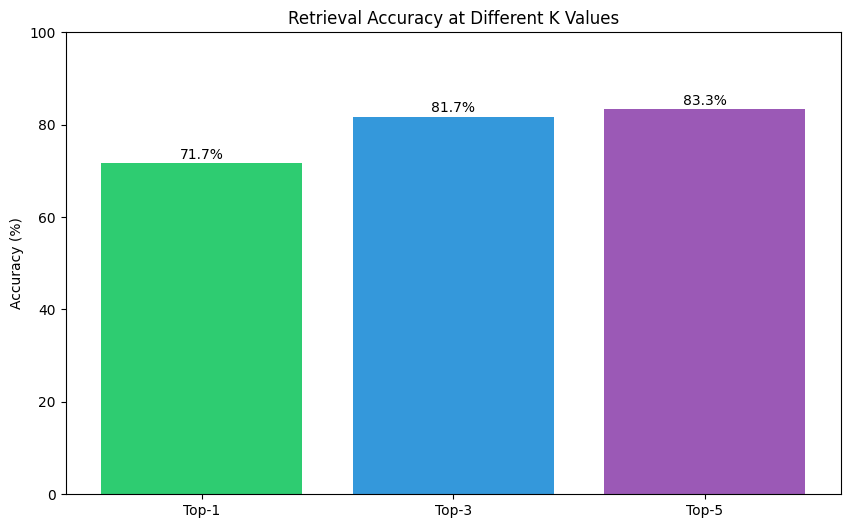

In [ ]:
import matplotlib.pyplot as plt

# Create bar plot
plt.figure(figsize=(10, 6))
metrics = ['Top-1', 'Top-3', 'Top-5']
values = [accuracy_results['top_1'], accuracy_results['top_3'], accuracy_results['top_5']]

plt.bar(metrics, values, color=['#2ecc71', '#3498db', '#9b59b6'])
plt.title('Retrieval Accuracy at Different K Values')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

# Add value labels on top of each bar
for i, v in enumerate(values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')

plt.show()

## ZeoSyn-based benchmarking using framework queries

We will:
- Load queries from `zeolite_synthesis_questions.txt`
- For each query, extract the framework code(s) (e.g., MFI, BEA, FAU; ignore decorations like `*` or `-`)
- Retrieve top-K documents from the FAISS vector DB and extract DOIs
- Load the ZeoSyn database (we only need `doi`, `Code1`, `Code2`, `Code3`)
- Count a hit@K if ANY of the top-K DOIs appears under ANY of the parsed framework codes in ZeoSyn

Please set `ZEOSYN_PATH` to the Excel/CSV file with those columns before running the evaluation cells below.

In [ ]:
# --- Helpers: DOI normalization, framework parsing, ZeoSyn loading, topK retrieval ---
import re
import pandas as pd
from collections import defaultdict
from typing import List, Dict, Set


def normalize_doi(doi: str) -> str:
    if doi is None:
        return ""
    d = str(doi).strip().lower()
    # remove common prefixes
    d = re.sub(r"^(https?://(dx\.)?doi\.org/)", "", d)
    d = re.sub(r"^doi:\s*", "", d)
    return d.strip()


def parse_frameworks_from_query(query: str) -> List[str]:
    """Extract framework code(s) from a question string.
    Examples:
      "Give me synthesis conditions for a *BEA/BEC recipe." -> ["BEA","BEC"]
      "Give me synthesis conditions for a EUO/*MRE recipe." -> ["EUO","MRE"]
      "Give me synthesis conditions for a ASU-12 recipe." -> ["ASU-12"]
      "Give me synthesis conditions for a -SVR recipe." -> ["SVR"]
    """
    # Try to capture the segment between 'for a ' and ' recipe'
    m = re.search(r"for a\s+(.*?)\s+recipe\.?", query, flags=re.IGNORECASE)
    segment = m.group(1) if m else query
    # Split on '/' first to handle combos
    parts = re.split(r"/", segment)
    frameworks = []
    for p in parts:
        # Strip leading decorations like '*' or '-' and trailing punctuation
        token = p.strip().strip('.').strip()
        token = re.sub(r"^[\*-]+", "", token)
        # Keep internal hyphens/digits (e.g., ASU-12)
        # Reduce multiple spaces
        token = re.sub(r"\s+", " ", token)
        token = token.upper()
        token = token.strip()
        if token:
            frameworks.append(token)
    # Some segments include extra words; try to filter by typical code patterns
    cleaned = []
    for t in frameworks:
        # Accept tokens of pattern AAA, AAA-12, or alphanum combos up to ~10 chars
        if re.match(r"^[A-Z]{2,}(?:-[0-9A-Z]+)?$", t):
            cleaned.append(t)
        else:
            # Try last all-caps chunk in token
            caps = re.findall(r"[A-Z]{2,}(?:-[0-9A-Z]+)?", t)
            cleaned.extend(caps)
    # Deduplicate preserving order
    seen = set()
    out = []
    for c in cleaned:
        if c not in seen:
            seen.add(c)
            out.append(c)
    return out


def load_zeosyn_framework_to_doi_map(path: str) -> Dict[str, Set[str]]:
    """Load ZeoSyn Excel/CSV and return mapping: FRAMEWORK_CODE -> set(normalized_doi)."""
    if path.lower().endswith(".csv"):
        df = pd.read_csv(path)
    else:
        # default to excel
        df = pd.read_excel(path)
    # Normalize columns
    cols = {c.lower(): c for c in df.columns}
    # Try to find doi and code columns case-insensitively
    doi_col = cols.get("doi")
    # Common variants
    if doi_col is None:
        for cand in df.columns:
            if cand.lower().startswith("doi"):
                doi_col = cand
                break
    code_cols = []
    for key in ["code1", "code2", "code3"]:
        if key in cols:
            code_cols.append(cols[key])
    # Fallback: any column named like 'code' variants
    if not code_cols:
        for cand in df.columns:
            if re.match(r"code[123]$", cand.lower()):
                code_cols.append(cand)
    if doi_col is None or not code_cols:
        raise ValueError("Could not locate 'doi' and 'Code1/Code2/Code3' columns in ZeoSyn file.")

    fmap: Dict[str, Set[str]] = defaultdict(set)
    for _, row in df.iterrows():
        doi = normalize_doi(row.get(doi_col, ""))
        if not doi:
            continue
        codes = []
        for c in code_cols:
            val = row.get(c)
            if pd.isna(val):
                continue
            code = str(val).strip().upper()
            if code:
                codes.append(code)
        for code in codes:
            fmap[code].add(doi)
    return fmap


def get_topk_unique_dois(vector_db, query: str, k: int) -> List[str]:
    docs = vector_db.similarity_search(query, k=k)
    dois = []
    for doc in docs:
        content = doc.page_content or ""
        # Prefer the explicit tag; else try to regex a DOI-looking string
        if "This information is from DOI:" in content:
            doi = content.split("This information is from DOI:")[-1].strip()
            doi = normalize_doi(doi)
            if doi:
                dois.append(doi)
        else:
            m = re.search(r"\b10\.\d{4,9}/[-._;()/:A-Z0-9]+", content, flags=re.IGNORECASE)
            if m:
                dois.append(normalize_doi(m.group(0)))
    # Deduplicate preserving order
    seen = set()
    ordered = []
    for d in dois:
        if d and d not in seen:
            seen.add(d)
            ordered.append(d)
    return ordered[:k]


def evaluate_questions_against_zeosyn(questions_path: str, vector_db, zeosyn_map: Dict[str, Set[str]], ks=(1,3,5)):
    # Load questions
    with open(questions_path, 'r') as f:
        questions = [q.strip() for q in f if q.strip()]

    totals = {k: 0 for k in ks}
    hits = {k: 0 for k in ks}
    per_question = []

    for q in tqdm(questions):
        frameworks = parse_frameworks_from_query(q)
        # Combine all ZeoSyn DOIs for these frameworks
        zeo_dois: Set[str] = set()
        for fw in frameworks:
            # Exact match
            if fw in zeosyn_map:
                zeo_dois |= zeosyn_map[fw]
            # Some frameworks may appear with leading '*' or '-' stripped already; try another heuristic:
            alt_fw = fw.lstrip("*- ")
            if alt_fw in zeosyn_map:
                zeo_dois |= zeosyn_map[alt_fw]
        result = {"question": q, "frameworks": frameworks, "zeosyn_dois_count": len(zeo_dois)}

        # Skip if we cannot map any DOI for the frameworks; we still count towards totals per your rule? We'll include and likely be miss unless retrieved DOI happens to be present.
        for k in ks:
            totals[k] += 1
            top_dois = get_topk_unique_dois(vector_db, q, k)
            matched = [d for d in top_dois if d in zeo_dois]
            hit = len(matched) > 0
            if hit:
                hits[k] += 1
            result[f"top{k}_dois"] = top_dois
            result[f"top{k}_hit"] = hit
            result[f"top{k}_matched"] = matched
        per_question.append(result)

    accuracies = {f"top_{k}": (hits[k] / totals[k] * 100 if totals[k] else 0.0) for k in ks}
    summary = {"totals": totals, "hits": hits, "accuracies": accuracies}
    return summary, per_question

In [ ]:
# --- Configure paths and run ZeoSyn evaluation ---
# Set to your actual ZeoSyn file path (Excel or CSV with columns: doi, Code1, Code2, Code3)
ZEOSYN_PATH = "ZEOSYN.xlsx" 
QUESTIONS_PATH = "zeolite_synthesis_questions.txt"  # provided

# Load ZeoSyn mapping
try:
    zeo_map = load_zeosyn_framework_to_doi_map(ZEOSYN_PATH)
    print(f"Loaded ZeoSyn map with {len(zeo_map)} framework entries")
except Exception as e:
    print("Failed to load ZeoSyn file:", e)
    zeo_map = {}

# Evaluate
summary, per_q = evaluate_questions_against_zeosyn(
    QUESTIONS_PATH,
    vector_db,
    zeo_map,
    ks=(1,3,5)
)

print("ZeoSyn Retrieval Accuracy (Hit@K by framework):")
for k, v in summary["accuracies"].items():
    print(f"  {k}: {v:.2f}%  (hits={summary['hits'][int(k.split('_')[1])]}/total={summary['totals'][int(k.split('_')[1])]})")

# Save detailed results
details_path_json = "zeosyn_benchmark_details.json"
with open(details_path_json, "w") as f:
    json.dump({"summary": summary, "results": per_q}, f, indent=2)
print(f"Saved detailed results to {details_path_json}")

Failed to load ZeoSyn file: [Errno 2] No such file or directory: 'zeosyn_database.xlsx'


100%|██████████| 233/233 [00:05<00:00, 42.52it/s]

ZeoSyn Retrieval Accuracy (Hit@K by framework):
  top_1: 0.00%  (hits=0/total=233)
  top_3: 0.00%  (hits=0/total=233)
  top_5: 0.00%  (hits=0/total=233)
Saved detailed results to zeosyn_benchmark_details.json


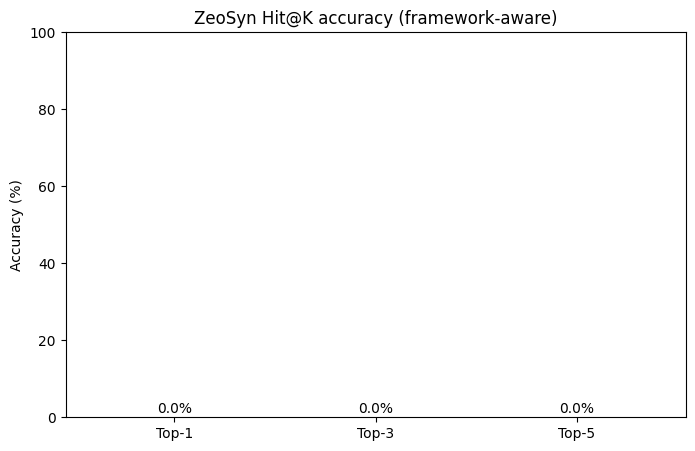

In [ ]:
# --- Optional: visualize ZeoSyn Hit@K ---
import matplotlib.pyplot as plt

labels = ["Top-1", "Top-3", "Top-5"]
vals = [summary["accuracies"]["top_1"], summary["accuracies"]["top_3"], summary["accuracies"]["top_5"]]
plt.figure(figsize=(8,5))
plt.bar(labels, vals, color=["#2ecc71", "#3498db", "#9b59b6"]) 
plt.ylim(0, 100)
for i, v in enumerate(vals):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.title("ZeoSyn Hit@K accuracy (framework-aware)")
plt.ylabel("Accuracy (%)")
plt.show()